In [1]:
import osmnx as ox
import geopandas as gpd
import networkx as nx
from shapely.geometry import Point, MultiPoint
import matplotlib.pyplot as plt
from pyrosm import OSM
from shapely.geometry import Polygon

BASE = "/home/jovyan/work/children15mc"
RAW = f"{BASE}/data/raw"
PROC = f"{BASE}/data/processed"
FIG = f"{BASE}/outputs/figures"
LOCAL_PBF = f"{RAW}/greater-london-260812.osm.pbf"

ox.settings.use_cache = True
ox.settings.cache_folder = f"{BASE}/cache"

CRS = 27700
WALK_SPEED_KMH = 3.5      # Child's walking speed
TRIP_MIN = 15

print("Configuration complete.")

Configuration complete.


In [2]:
#1. Read the table and test one borough first
df = gpd.read_file(f"{PROC}/analysis_table.gpkg")
test_borough = "Camden"
sub = df[df["lad22nm"] == test_borough].copy()
print(f"{test_borough}: {len(sub)} LSOAs")

Camden: 130 LSOAs


In [3]:
#2. Extract the pedestrian network for that borough
from shapely.geometry import box

# Extend 500 meters outward to avoid boundary truncation
poly_27700 = sub.geometry.union_all().buffer(500)
# Transform to 4326 (lat/lon) to use with osmnx
poly_4326 = gpd.GeoSeries([poly_27700], crs=27700).to_crs(4326).iloc[0]

G = ox.graph_from_polygon(poly_4326, network_type="walk", simplify=True)
print(f"Network: {len(G.nodes)} nodes, {len(G.edges)} edges")

Network: 21701 nodes, 58122 edges


In [4]:
#3. Calculate walking time
m_per_min = WALK_SPEED_KMH * 1000 / 60
for u, v, k, d in G.edges(keys=True, data=True):
    d["walk_time"] = d["length"] / m_per_min

In [5]:
#4. Isochrone function
def make_isochrone(G, x27700, y27700, trip_min=15, buff=30):
    pt = gpd.GeoSeries([Point(x27700, y27700)], crs=27700).to_crs(4326).iloc[0]
    node = ox.distance.nearest_nodes(G, pt.x, pt.y)
    sub_g = nx.ego_graph(G, node, radius=trip_min, distance="walk_time")
    pts = [Point(d["x"], d["y"]) for _, d in sub_g.nodes(data=True)]
    if len(pts) < 3:
        return Polygon()
    poly = gpd.GeoSeries(MultiPoint(pts), crs=4326).to_crs(27700)
    return poly.convex_hull.buffer(buff).iloc[0]

In [6]:
#5. Test
row0 = sub.iloc[0]
iso0 = make_isochrone(G, row0.cent_x, row0.cent_y, TRIP_MIN)
print(f"Area of a single isochronal circle: {iso0.area/1e6:.2f} km²")

Area of a single isochronal circle: 1.27 km²


In [7]:
from tqdm.notebook import tqdm

#6. Perform a full test using Camden
iso_rows = []
for _, row in tqdm(sub.iterrows(), total=len(sub), desc="Camden isochrones"):
    geom = make_isochrone(G, row.cent_x, row.cent_y, TRIP_MIN)
    iso_rows.append({"lsoa21cd": row.lsoa21cd, "geometry": geom})

iso_camden = gpd.GeoDataFrame(iso_rows, crs=CRS).dropna(subset=["geometry"])
print(f"Successfully generated {len(iso_camden)} / {len(sub)} isochrones")
print(f"Area range: {iso_camden.area.min()/1e6:.2f} – {iso_camden.area.max()/1e6:.2f} km²")

Camden isochrones:   0%|          | 0/130 [00:00<?, ?it/s]

Successfully generated 130 / 130 isochrones
Area range: 0.55 – 1.81 km²


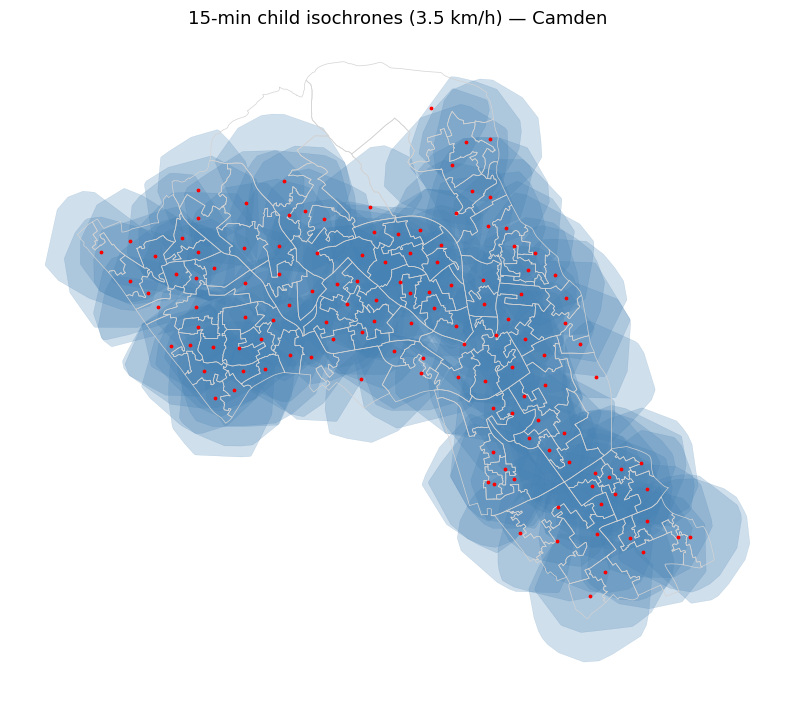

In [8]:
#7. Verify by drawing a diagram
fig, ax = plt.subplots(figsize=(10, 10))
sub.boundary.plot(ax=ax, color="lightgray", lw=0.5)
iso_camden.plot(ax=ax, alpha=0.25, color="steelblue", edgecolor="steelblue", lw=0.3)
ax.scatter(sub.cent_x, sub.cent_y, s=3, color="red", zorder=5)
ax.set_title(f"15-min child isochrones (3.5 km/h) — {test_borough}", fontsize=13)
ax.set_axis_off()
plt.savefig(f"{FIG}/test_isochrones_camden.png", dpi=150, bbox_inches="tight")
plt.show()